# **Aprendizado de Máquina** <BR>**Aula 04** - Regressão logística binária e problemas de classificação

# **Exemplo 1**: rolamentos

## **1)** Importação de bibliotecas e classes

In [1]:
# Bibliotecas de cálculo, manipulação de dados e geração de gráficos
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
# Bibliotecas específicas de Machine Learning
from sklearn.linear_model import LogisticRegression   # NOVIDADE!

## **2)** Leitura de dados e exploração inicial

In [4]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [3]:
# ATENÇÃO: "monte" o disco e ajuste o caminho do arquivo de dados
# antes da executar esta célula!

# Leitura dos dados de TREINO e exibição do DataFrame
df_treino = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Datasets/A04EXEMPLO1_treino.csv")
display(df_treino)

,Temp,Falha
0,46,0
1,54,0
2,45,0
3,68,0
4,51,0
5,72,0
6,50,0
7,76,1
8,81,1
9,70,1


### **2.1)** Caracaterísticas gerais

In [5]:
# Contagem de classes da resposta/target
print("0 = Não falha; 1 = Falha:\n")  # "\n" gera um salto de linha
print(df_treino['Falha'].value_counts())

0 = Não falha; 1 = Falha:

Falha
0    7
1    7
Name: count, dtype: int64


### **2.2)** Gráfico

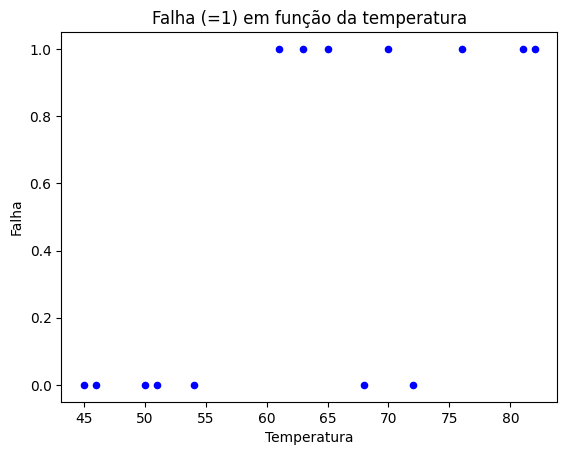

In [6]:
# Diagrama de dispersão entre a ocorrência de falha (y) e a temperatura
df_treino.plot.scatter(x = 'Temp',y = 'Falha',color = 'blue')
plt.title("Falha (=1) em função da temperatura")
plt.xlabel("Temperatura")
plt.ylabel("Falha")
plt.show()

## **3)** Seleção de variáveis

In [7]:
X_treino = df_treino[['Temp']]  # Atributo: temperatura
y_treino = df_treino['Falha']   # Resposta/target: condição de falha ("y = 1")

In [ ]:
# OBS.: se fosse necessário separar os dados disponíveis (X,y) em conjuntos de treino e teste:
# X_treino, X_teste, y_treino, y_teste = train_test_split(X,y,train_size = ??,random_state = ??)

# Parâmetros da função 'train_test_split':
# X,y = arrays (ou equivalentes) das variáveis independentes (X) e dependente (y)
# train_size/test_size = percentual de dados de treino/teste. Padrão: 75% (treino) e 25% (teste)
# random_state = controle (valor inteiro) da aleatoriedade da divisão

## **4)** Treinamento do <u>classificador</u> (modelo de regressão logística binária)

In [8]:
clf_RL = LogisticRegression()   # Cria instância de um classificador por reg. log. binária
clf_RL.fit(X_treino,y_treino)   # Treina o classificador

# Exibição dos coeficientes do modelo
print("Beta0 =",clf_RL.intercept_)
print("Beta1 =",clf_RL.coef_)

Beta0 = [-10.3515217]
Beta1 = [[0.16355948]]


## **5)** Previsões pontuais (*Temp* = 58 e *Temp* = 75)

In [9]:
# Criação de um DICIONÁRIO com os dados de previsão
X_prev_dict = {'Temp': [58, 75]}

# Conversão do dicionário em um DataFrame
X_prev_df = pd.DataFrame(data = X_prev_dict)
X_prev_df

,Temp
0,58
1,75


In [10]:
# Cálculo das PROBABILIDADES previstas: método "predict_proba"
# Exibe P(Falha|Temp = 58) e P(Falha|Temp = 75)
# Serão mostradas duas colunas, com P(y=0) e P(y=1)

print("Probabilidades previstas:")
print(clf_RL.predict_proba(X_prev_df))

Probabilidades previstas:
[[0.70371918 0.29628082]
 [0.12837098 0.87162902]]


In [11]:
# CLASSIFICAÇÕES previstas: método "predict"

print("Classificações previstas:")
print(clf_RL.predict(X_prev_df))

Classificações previstas:
[0 1]


## **6)** Representação gráfica do modelo (opcional)

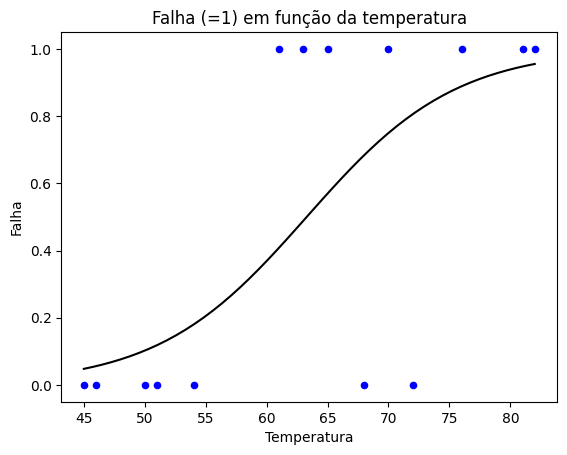

In [12]:
# Recria o diagrama de dispersão
df_treino.plot.scatter(x = 'Temp',y = 'Falha',color = 'blue')
plt.title("Falha (=1) em função da temperatura")
plt.xlabel("Temperatura")
plt.ylabel("Falha")

# Cria um array com 50 valores para a "temperatura"
X_graf = np.linspace(start = np.min(df_treino['Temp']),
                     stop = np.max(df_treino['Temp']),
                     num = 50)
X_graf = X_graf.reshape(-1,1)   # Ajusta as dimensões: 50 linhas, 1 coluna

X_graf_df = pd.DataFrame(data = X_graf,columns = ['Temp'])  # Cria DF para usar 'predict_proba'
y_graf = clf_RL.predict_proba(X_graf_df)   # Calcula os valores de y correspondentes

# Traça a curva do modelo sobre o diagrama de dispersão
plt.plot(X_graf,y_graf[:,1],color = 'black')  # Obs.: usa a segunda coluna de "y_graf"
plt.show()    # "Consolida" a exibição dos gráficos

## **7)** Avaliação <u>preliminar</u> da qualidade do classificador (usando os dados de treino)

In [13]:
# Avaliação PRELIMINAR, via acurácia de ressubstituição
from sklearn.metrics import accuracy_score

# Calcula as previsões do classificador para os dados de treino (ressubstituição)
y_prev_treino = clf_RL.predict(X_treino)

# Acurácia
print("'Acurácia preliminar' =",accuracy_score(y_true = y_treino,y_pred = y_prev_treino))

'Acurácia preliminar' = 0.7142857142857143


## **8)** Avaliação da qualidade do classificador: validação cruzada *hold-out*

In [14]:
# Leitura dos dados de TESTE e exibição do DataFrame
df_teste = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Datasets/A04EXEMPLO1_teste.csv")
display(df_teste)

,Temp,Falha
0,61,0
1,67,0
2,62,1
3,81,1
4,69,1
5,54,0
6,75,1
7,50,1
8,58,0
9,70,1


In [15]:
# Cálculo da acurácia
from sklearn.metrics import accuracy_score

# Seleção dos dados (teste)
y_teste = df_teste['Falha']
X_teste = df_teste[['Temp']]

y_prev_teste = clf_RL.predict(X_teste)  # Previsões para os dados de teste
print("Acurácia =",accuracy_score(y_true = y_teste,y_pred = y_prev_teste))

Acurácia = 0.7


In [16]:
# Exibição "básica" da matriz de confusão
from sklearn.metrics import confusion_matrix

confusion_matrix(y_true = y_teste,y_pred = y_prev_teste)

array([[3, 1],
       [2, 4]])

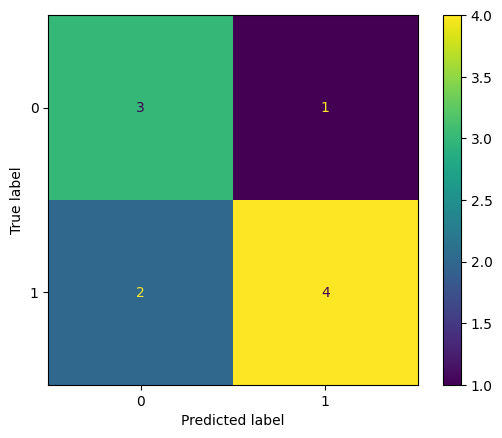

In [17]:
# Representação "gráfica" da matriz de confusão
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_true = y_teste,y_pred = y_prev_teste)
plt.show()

In [18]:
# Relatório das métricas de qualidade
from sklearn.metrics import classification_report

print(classification_report(y_true = y_teste,y_pred = y_prev_teste,digits = 4))

              precision    recall  f1-score   support

           0     0.6000    0.7500    0.6667         4
           1     0.8000    0.6667    0.7273         6

    accuracy                         0.7000        10
   macro avg     0.7000    0.7083    0.6970        10
weighted avg     0.7200    0.7000    0.7030        10



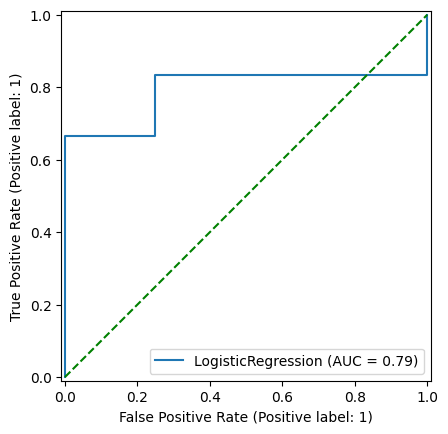

In [19]:
# Exibição da curva ROC
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(estimator = clf_RL,X = X_teste,y = y_teste)

# Acrescenta ao gráfico a curva ROC de um modelo puramente aleatório
plt.plot([0,1],[0,1],'g--')   # Linha verde (color = 'green') tracejada
plt.show()

---
**Fim do Exemplo 1 da Aula 04**